# Dataset Loading

In [3]:
import pandas as pd

df = pd.read_csv('house data.csv') 
df.head() 

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


#### The dataset includes multiple property-related features such as size, location and condition that influence house prices.

# Basic Inspection

In [4]:
print(df.shape)

(4600, 18)


In [5]:
print(df.columns)

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [7]:
print(df.describe())

              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   862.168977   
min       

# Data Preprocessing

## Check Missing Values

In [8]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

## Convert Date, Year, Month

In [11]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.drop('date', axis=1, inplace=True)

## Drop useless columns

In [12]:
df.drop(['street', 'country'], axis=1, inplace=True)

## Encode Categorical Features

In [13]:
df = pd.get_dummies(df, columns=['city', 'statezip'], drop_first=True)

### Irrelevant features like street and country were removed while date was converted into year and month.

### Categorical variables like city were encoded.

# Features & Target

In [14]:
X = df.drop('price', axis=1)
y = df['price']

# Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Feature scaling was applied to normalize the input variables so that all features contribute equally to the model. 
    
#### This helps improve model performance and ensures faster and more stable training.

#### Feature scaling was applied to normalize the input variables so that all features contribute equally to the model. 
    
#### This helps improve model performance and ensures faster and more stable training.

# Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model ( Gradient Boosting )

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### A Gradient Boosting model was used to capture complex relationships between features and house prices.

# Predictions

In [23]:
y_pred = model.predict(X_test)
y_pred

array([ 431536.97256794,  362070.82632271, 1040145.46334619,
        417009.17532595,  279629.56733259,  569858.14729979,
        559400.90967931,  358387.59396416,  491982.69382267,
        723851.18015066,  589621.22530957,  448602.32452459,
        796499.75241204,  399494.75357653,  330132.47229017,
        965284.68214555,  569858.14729979,  569858.14729979,
       1130697.56890067,  768785.68464421,  963956.83702568,
        569858.14729979,  588599.15985962,  496847.49087524,
        356810.8453273 ,  173077.77716114,  661531.48383887,
        980538.09130494,  439021.85998001,  806873.9737541 ,
       1607328.99297051,  309539.09268462, 1240591.33399287,
        351990.03206865,  258469.7843421 ,  418460.40262688,
        612832.99864028,  828009.91175438,  215749.09903407,
        540743.51622314,  351491.21231211,  379364.47658205,
        424643.48464273,  644713.5125443 ,  308210.95446955,
        401422.65964895,  291259.37722609,  571034.58601332,
       1019996.53356464,

### The model generated price predictions that follow the general trend of actual values.

# Evaluation

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 156841.57568012015
RMSE: 980123.1596432007


### MAE and RMSE indicate that the model has a reasonable prediction error with RMSE highlighting larger 
### deviations.

# Visualization

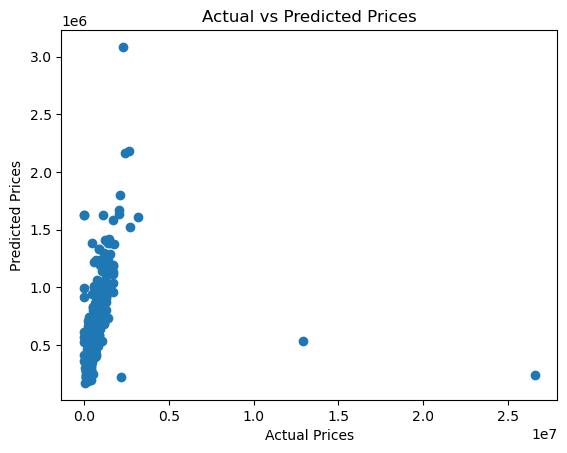

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# Training vs Testing Performance

In [22]:
from sklearn.metrics import r2_score

# Training score
train_r2 = model.score(X_train, y_train)

# Testing score
test_r2 = model.score(X_test, y_test)

print("Training R2:", train_r2)
print("Testing R2:", test_r2)

Training R2: 0.8255877211152576
Testing R2: 0.05805279647611972


# Overall Insight

## Location, living area and property condition play a significant role in determining house prices.